In [1]:
import pandas as pd

# Load XRP CSV
xrp_df = pd.read_csv(r'feature_datasets\XRP_features.csv', parse_dates=True, index_col=0)

# Define X and y
xrp_y = xrp_df['Close'].shift(-1)          # next-day close price
xrp_X = xrp_df.drop(columns=['Close'])     # all other features

# Drop last row (y will be NaN)
xrp_X = xrp_X.iloc[:-1]
xrp_y = xrp_y.iloc[:-1]

# Optional: check shapes
print("XRP X shape:", xrp_X.shape)
print("XRP y shape:", xrp_y.shape)

XRP X shape: (915, 29)
XRP y shape: (915,)


## 70-30 split

In [2]:
# 70% train / 30% test split (time-based)
split_idx = int(len(xrp_X) * 0.7)

xrp_X_train = xrp_X.iloc[:split_idx].values
xrp_X_test  = xrp_X.iloc[split_idx:].values

xrp_y_train = xrp_y.iloc[:split_idx].values
xrp_y_test  = xrp_y.iloc[split_idx:].values

print("XRP X_train shape:", xrp_X_train.shape)
print("XRP X_test shape:", xrp_X_test.shape)
print("XRP y_train shape:", xrp_y_train.shape)
print("XRP y_test shape:", xrp_y_test.shape)

XRP X_train shape: (640, 29)
XRP X_test shape: (275, 29)
XRP y_train shape: (640,)
XRP y_test shape: (275,)


In [3]:
xrp_test_dates = xrp_df.index[-len(xrp_X_test):]

In [4]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN only
xrp_X_train_scaled = scaler.fit_transform(xrp_X_train)

# Transform TEST using the same scaler
xrp_X_test_scaled = scaler.transform(xrp_X_test)

# Check shapes
print("Scaled X_train shape:", xrp_X_train_scaled.shape)
print("Scaled X_test shape:", xrp_X_test_scaled.shape)

Scaled X_train shape: (640, 29)
Scaled X_test shape: (275, 29)


In [5]:
# Initialize scaler for y
y_scaler = MinMaxScaler()

# Scale training target
xrp_y_train_scaled = y_scaler.fit_transform(xrp_y_train.reshape(-1,1)).flatten()

# Scale test target
xrp_y_test_scaled = y_scaler.transform(xrp_y_test.reshape(-1,1)).flatten()

In [6]:
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for XRP using scaled target
xrp_X_train_seq, xrp_y_train_seq = create_sequences(xrp_X_train_scaled, xrp_y_train_scaled, time_steps=30)
xrp_X_test_seq, xrp_y_test_seq = create_sequences(xrp_X_test_scaled, xrp_y_test_scaled, time_steps=30)

# Check shapes
print("XRP X_train_seq shape:", xrp_X_train_seq.shape)
print("XRP y_train_seq shape:", xrp_y_train_seq.shape)
print("XRP X_test_seq shape:", xrp_X_test_seq.shape)
print("XRP y_test_seq shape:", xrp_y_test_seq.shape)

XRP X_train_seq shape: (610, 30, 29)
XRP y_train_seq shape: (610,)
XRP X_test_seq shape: (245, 30, 29)
XRP y_test_seq shape: (245,)


### Model training

In [7]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [8]:
# Get number of features from the sequences
input_size = xrp_X_train_seq.shape[2]

# Initialize Bi-LSTM model
model = BiLSTM(input_size=input_size)

In [9]:
model = train_model(model, xrp_X_train_seq, xrp_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.004503
Epoch [20/50], Loss: 0.006899
Epoch [30/50], Loss: 0.001480
Epoch [40/50], Loss: 0.001388
Epoch [50/50], Loss: 0.001358


In [10]:
xrp_preds = predict_model(model, xrp_X_test_seq)

# check
print("Predictions shape:", xrp_preds.shape)
print("First 10 predictions:", xrp_preds[:10])

Predictions shape: (245, 1)
First 10 predictions: [[0.14032738]
 [0.1290898 ]
 [0.12257698]
 [0.11460143]
 [0.10896577]
 [0.10670756]
 [0.10471065]
 [0.09811549]
 [0.0858593 ]
 [0.08232352]]


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale predictions
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds.reshape(-1,1))

# Skip first 30 because of 30-day sequence
xrp_y_test_actual = xrp_y_test[30:].reshape(-1,1)

# Calculate metrics
mse = mean_squared_error(xrp_y_test_actual, xrp_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(xrp_y_test_actual, xrp_preds_actual)
r2 = r2_score(xrp_y_test_actual, xrp_preds_actual)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.00
RMSE: 0.07
MAE: 0.04
R2 Score: 0.4032


In [12]:
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds.reshape(-1,1))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Skip first 30 because of sequence
dates_seq = xrp_df.index[-len(xrp_X_test):][30:]  # test dates aligned with sequences
actual_seq = xrp_y_test[30:]                      # actual prices aligned
pred_seq = xrp_preds_actual                       # predicted prices aligned

# Create DataFrame
df_plot = pd.DataFrame({
    "Date": dates_seq,
    "Actual": actual_seq,
    "Predicted": pred_seq.flatten()
})

df_plot.set_index("Date", inplace=True)
df_plot

,Actual,Predicted
Date,,
2023-05-02,0.464951,0.459829
2023-05-03,0.463494,0.447678
2023-05-04,0.461573,0.440635
2023-05-05,0.467800,0.432011
2023-05-06,0.459549,0.425917
...,...,...
2023-12-28,0.634998,0.501445
2023-12-29,0.623402,0.505214
2023-12-30,0.621844,0.508163


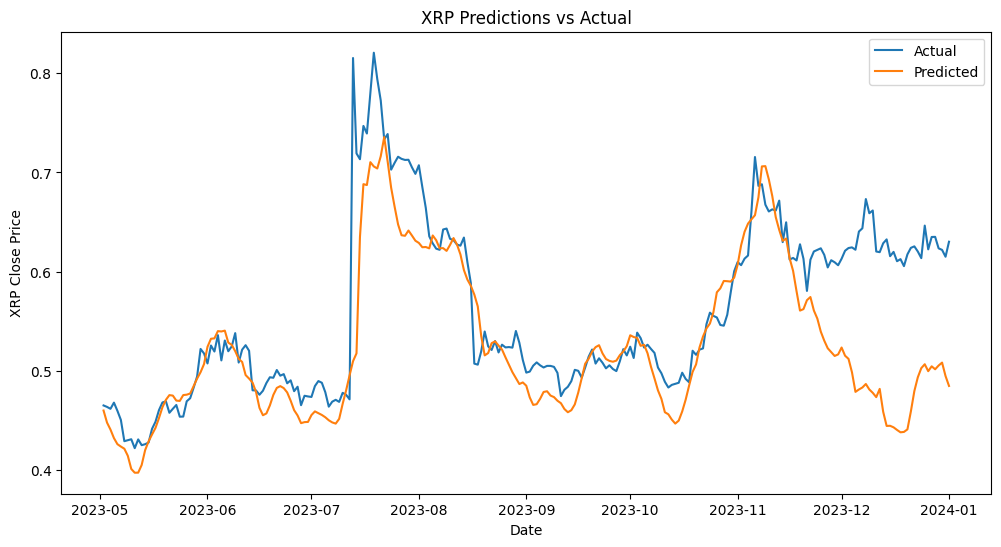

In [14]:
plt.figure(figsize=(12,6))
plt.plot(df_plot["Actual"], label="Actual")
plt.plot(df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("XRP Close Price")
plt.title("XRP Predictions vs Actual")
plt.legend()
plt.show()

## 70% from each year split

In [15]:
# Get unique years from your DataFrame index
years = xrp_df.index.year.unique()
print("Years in dataset:", years)

Years in dataset: Index([2021, 2022, 2023, 2024], dtype='int32', name='Date')


In [16]:
X_train_list = []
y_train_list = []

In [17]:
for year in years:
    # Filter data for this year
    xrp_year = xrp_df[xrp_df.index.year == year]

    # Calculate split index for 70%
    split_idx = int(len(xrp_year) * 0.7)

    # Take first 70% as training
    X_train_year = xrp_year.iloc[:split_idx, 1:].values  # all features except target column
    y_train_year = xrp_year.iloc[:split_idx, 0].values   # target column (e.g., next-day Close)

    # Append to lists
    X_train_list.append(X_train_year)
    y_train_list.append(y_train_year)

    print(f"Year {year}: {len(X_train_year)} train samples")

Year 2021: 129 train samples
Year 2022: 255 train samples
Year 2023: 255 train samples
Year 2024: 0 train samples


In [18]:
import numpy as np

# Stack all years’ train sets
X_train_combined = np.vstack(X_train_list)
y_train_combined = np.hstack(y_train_list)

print("Combined X_train shape:", X_train_combined.shape)
print("Combined y_train shape:", y_train_combined.shape)

Combined X_train shape: (639, 29)
Combined y_train shape: (639,)


In [19]:
X_test_list = []
y_test_list = []

In [20]:
for year in years:
    xrp_year = xrp_df[xrp_df.index.year == year]

    # Calculate split index (same as for train)
    split_idx = max(1, int(len(xrp_year) * 0.7))  # ensures at least 1 sample in train

    # Take the remaining 30% as test
    X_test_year = xrp_year.iloc[split_idx:, 1:].values   # features
    y_test_year = xrp_year.iloc[split_idx:, 0].values    # target

    # Append to test lists
    X_test_list.append(X_test_year)
    y_test_list.append(y_test_year)

    print(f"Year {year}: {len(X_test_year)} test samples")

Year 2021: 56 test samples
Year 2022: 110 test samples
Year 2023: 110 test samples
Year 2024: 0 test samples


In [21]:
import numpy as np

X_test_combined = np.vstack(X_test_list)
y_test_combined = np.hstack(y_test_list)

print("Combined X_test shape:", X_test_combined.shape)
print("Combined y_test shape:", y_test_combined.shape)

Combined X_test shape: (276, 29)
Combined y_test shape: (276,)


In [22]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Scale training data
X_train_scaled = x_scaler.fit_transform(X_train_combined)
y_train_scaled = y_scaler.fit_transform(y_train_combined.reshape(-1,1)).flatten()

In [23]:
X_test_scaled = x_scaler.transform(X_test_combined)
y_test_scaled = y_scaler.transform(y_test_combined.reshape(-1,1)).flatten()

print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
print("Scaled y_train shape:", y_train_scaled.shape)
print("Scaled y_test shape:", y_test_scaled.shape)

Scaled X_train shape: (639, 29)
Scaled X_test shape: (276, 29)
Scaled y_train shape: (639,)
Scaled y_test shape: (276,)


In [24]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])  # the next day after the sequence
    return np.array(X_seq), np.array(y_seq)

# Create sequences for XRP train and test
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled)

# Check shapes
print("XRP X_train_seq shape:", X_train_seq.shape)
print("XRP y_train_seq shape:", y_train_seq.shape)
print("XRP X_test_seq shape:", X_test_seq.shape)
print("XRP y_test_seq shape:", y_test_seq.shape)

XRP X_train_seq shape: (609, 30, 29)
XRP y_train_seq shape: (609,)
XRP X_test_seq shape: (246, 30, 29)
XRP y_test_seq shape: (246,)


### Model training

In [25]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [26]:
# Get number of features from the sequences
input_size = X_train_seq.shape[2]   # use the combined train sequences

# Initialize Bi-LSTM model for XRP
model_y = BiLSTM(input_size=input_size)

In [27]:
model_y = train_model(model_y, X_train_seq, y_train_seq, epochs=50, batch_size=32, lr=0.001)

c:\Users\tharu\anaconda3\envs\Streamlit\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/50], Loss: 0.007673
Epoch [20/50], Loss: 0.003939
Epoch [30/50], Loss: 0.001852
Epoch [40/50], Loss: 0.001425
Epoch [50/50], Loss: 0.002121


In [28]:
xrp_preds_ev_year = predict_model(model_y, X_test_seq)
xrp_preds_ev_year[:10]

array([[0.4330546 ],
       [0.43897805],
       [0.43765956],
       [0.44179827],
       [0.4578787 ],
       [0.44203565],
       [0.42072862],
       [0.41517693],
       [0.39134485],
       [0.39434093]], dtype=float32)

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the trained model
xrp_preds_ev_year = predict_model(model_y, X_test_seq)

# Inverse scale predictions to original price values
xrp_preds_actual = y_scaler.inverse_transform(xrp_preds_ev_year.reshape(-1,1))

# Inverse scale the test targets
xrp_y_test_actual = y_scaler.inverse_transform(y_test_seq.reshape(-1,1))

# Calculate metrics
mse = mean_squared_error(xrp_y_test_actual, xrp_preds_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(xrp_y_test_actual, xrp_preds_actual)
r2 = r2_score(xrp_y_test_actual, xrp_preds_actual)

# Print results
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

MSE: 0.01
RMSE: 0.07
MAE: 0.05
R2 Score: 0.7397


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Actual and predicted prices
actual_test_seq = y_scaler.inverse_transform(y_test_seq.reshape(-1,1)).flatten()
predicted_test_seq = xrp_preds_actual.flatten()

# Create DataFrame for plotting (no Date index)
df_xrp_plot_year = pd.DataFrame({
    "Actual": actual_test_seq,
    "Predicted": predicted_test_seq
})

# Display first few rows
df_xrp_plot_year.head()

,Actual,Predicted
0,0.828288,0.776362
1,0.818588,0.782767
2,0.863307,0.781341
3,0.861272,0.785817
4,0.801097,0.803205


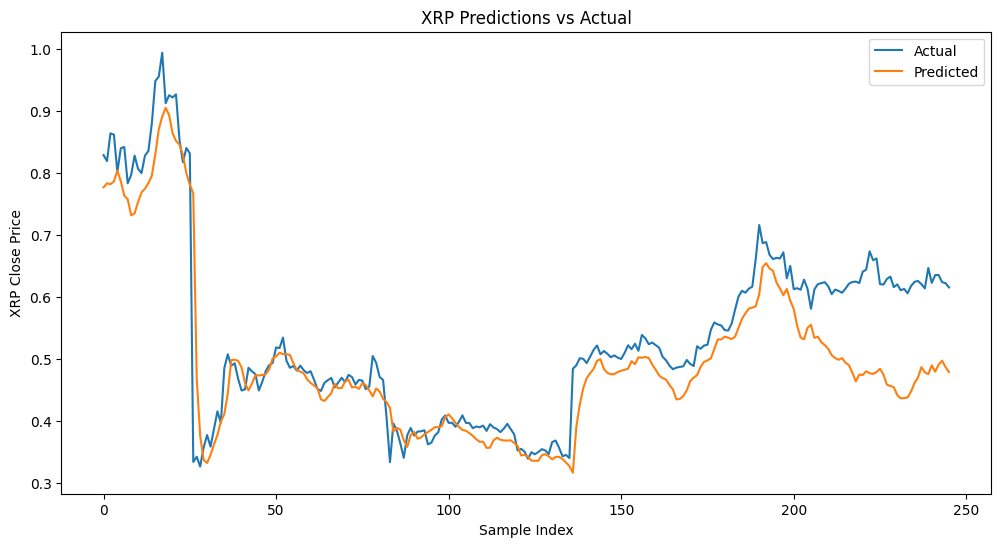

In [31]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_xrp_plot_year["Actual"], label="Actual")
plt.plot(df_xrp_plot_year["Predicted"], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("XRP Close Price")
plt.title("XRP Predictions vs Actual")
plt.legend()
plt.show()

## Three quaters split model training

In [32]:
# 75% train / 25% test split (time-based)
q3_split_idx = int(len(xrp_X) * 0.75)

xrp_q3_X_train = xrp_X.iloc[:q3_split_idx].values
xrp_q3_X_test  = xrp_X.iloc[q3_split_idx:].values

xrp_q3_y_train = xrp_y.iloc[:q3_split_idx].values
xrp_q3_y_test  = xrp_y.iloc[q3_split_idx:].values

# Shape checks
print("Q3 XRP X_train shape:", xrp_q3_X_train.shape)
print("Q3 XRP X_test shape:", xrp_q3_X_test.shape)
print("Q3 XRP y_train shape:", xrp_q3_y_train.shape)
print("Q3 XRP y_test shape:", xrp_q3_y_test.shape)

Q3 XRP X_train shape: (686, 29)
Q3 XRP X_test shape: (229, 29)
Q3 XRP y_train shape: (686,)
Q3 XRP y_test shape: (229,)


In [33]:
# Assuming xrp_df has Date as index
xrp_q3_test_dates = xrp_df.index[-len(xrp_q3_X_test):]

print("Q3 test dates length:", len(xrp_q3_test_dates))

Q3 test dates length: 229


In [34]:
from sklearn.preprocessing import MinMaxScaler

# Feature scaler
xrp_q3_X_scaler = MinMaxScaler()

# Fit on TRAIN only
xrp_q3_X_train_scaled = xrp_q3_X_scaler.fit_transform(xrp_q3_X_train)

# Transform TEST using same scaler
xrp_q3_X_test_scaled = xrp_q3_X_scaler.transform(xrp_q3_X_test)

print("Q3 Scaled X_train shape:", xrp_q3_X_train_scaled.shape)
print("Q3 Scaled X_test shape:", xrp_q3_X_test_scaled.shape)

Q3 Scaled X_train shape: (686, 29)
Q3 Scaled X_test shape: (229, 29)


In [35]:
# Target scaler
xrp_q3_y_scaler = MinMaxScaler()

# Scale training target
xrp_q3_y_train_scaled = xrp_q3_y_scaler.fit_transform(
    xrp_q3_y_train.reshape(-1, 1)
).flatten()

# Scale test target
xrp_q3_y_test_scaled = xrp_q3_y_scaler.transform(
    xrp_q3_y_test.reshape(-1, 1)
).flatten()

print("Q3 Scaled y_train shape:", xrp_q3_y_train_scaled.shape)
print("Q3 Scaled y_test shape:", xrp_q3_y_test_scaled.shape)

Q3 Scaled y_train shape: (686,)
Q3 Scaled y_test shape: (229,)


In [36]:
import numpy as np

def create_sequences_q3(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

In [37]:
# Create sequences (30-day window) for XRP
xrp_q3_X_train_seq, xrp_q3_y_train_seq = create_sequences_q3(
    xrp_q3_X_train_scaled,
    xrp_q3_y_train_scaled,
    time_steps=30
)

xrp_q3_X_test_seq, xrp_q3_y_test_seq = create_sequences_q3(
    xrp_q3_X_test_scaled,
    xrp_q3_y_test_scaled,
    time_steps=30
)

# Final shape checks
print("Q3 XRP X_train_seq shape:", xrp_q3_X_train_seq.shape)
print("Q3 XRP y_train_seq shape:", xrp_q3_y_train_seq.shape)
print("Q3 XRP X_test_seq shape:", xrp_q3_X_test_seq.shape)
print("Q3 XRP y_test_seq shape:", xrp_q3_y_test_seq.shape)

Q3 XRP X_train_seq shape: (656, 30, 29)
Q3 XRP y_train_seq shape: (656,)
Q3 XRP X_test_seq shape: (199, 30, 29)
Q3 XRP y_test_seq shape: (199,)


### Model training

In [38]:
from Bi_LSTM import BiLSTM, train_model, predict_model

In [39]:
# Get number of features
xrp_q3_input_size = xrp_q3_X_train_seq.shape[2]

# Initialize model
xrp_q3_model = BiLSTM(input_size=xrp_q3_input_size)

In [40]:
# Train model
xrp_q3_model = train_model(xrp_q3_model, xrp_q3_X_train_seq, xrp_q3_y_train_seq, epochs=50, batch_size=32, lr=0.001)

Epoch [10/50], Loss: 0.002782
Epoch [20/50], Loss: 0.007873
Epoch [30/50], Loss: 0.002690
Epoch [40/50], Loss: 0.001688
Epoch [50/50], Loss: 0.002149


In [41]:
# Generate predictions
xrp_q3_preds = predict_model(xrp_q3_model, xrp_q3_X_test_seq)

print("Q3 Predictions shape:", xrp_q3_preds.shape)
print("First 10 Q3 predictions:", xrp_q3_preds[:10])

Q3 Predictions shape: (199, 1)
First 10 Q3 predictions: [[0.12087025]
 [0.12227273]
 [0.12709625]
 [0.13466756]
 [0.13843128]
 [0.13883454]
 [0.13863076]
 [0.13627636]
 [0.13018441]
 [0.12286676]]


In [42]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict using the Q3 trained model
xrp_q3_preds_eval = predict_model(xrp_q3_model, xrp_q3_X_test_seq)

# Inverse scale predictions to original price values
xrp_q3_preds_actual = xrp_q3_y_scaler.inverse_transform(
    xrp_q3_preds_eval.reshape(-1, 1)
)

# Inverse scale the test targets
xrp_q3_y_test_actual = xrp_q3_y_scaler.inverse_transform(
    xrp_q3_y_test_seq.reshape(-1, 1)
)

# Calculate metrics
xrp_q3_mse = mean_squared_error(xrp_q3_y_test_actual, xrp_q3_preds_actual)
xrp_q3_rmse = np.sqrt(xrp_q3_mse)
xrp_q3_mae = mean_absolute_error(xrp_q3_y_test_actual, xrp_q3_preds_actual)
xrp_q3_r2 = r2_score(xrp_q3_y_test_actual, xrp_q3_preds_actual)

# Print results
print(f"Q3 MSE: {xrp_q3_mse:.2f}")
print(f"Q3 RMSE: {xrp_q3_rmse:.2f}")
print(f"Q3 MAE: {xrp_q3_mae:.2f}")
print(f"Q3 R2 Score: {xrp_q3_r2:.4f}")

Q3 MSE: 0.01
Q3 RMSE: 0.11
Q3 MAE: 0.09
Q3 R2 Score: -0.6073


In [43]:
# Inverse scale predictions
xrp_q3_preds_actual = xrp_q3_y_scaler.inverse_transform(
    xrp_q3_preds.reshape(-1, 1)
)

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Align dates and values for XRP Q3 predictions
xrp_q3_dates_seq = xrp_df.index[-len(xrp_q3_X_test):][30:]
xrp_q3_actual_seq = xrp_q3_y_test[30:]
xrp_q3_pred_seq = xrp_q3_preds_actual.flatten()

# Create DataFrame
xrp_q3_df_plot = pd.DataFrame({
    "Date": xrp_q3_dates_seq,
    "Actual": xrp_q3_actual_seq,
    "Predicted": xrp_q3_pred_seq
})

xrp_q3_df_plot.set_index("Date", inplace=True)
xrp_q3_df_plot

,Actual,Predicted
Date,,
2023-06-17,0.479790,0.438790
2023-06-18,0.487573,0.440306
2023-06-19,0.493395,0.445522
2023-06-20,0.492870,0.453709
2023-06-21,0.500695,0.457779
...,...,...
2023-12-28,0.634998,0.475371
2023-12-29,0.623402,0.474495
2023-12-30,0.621844,0.475092


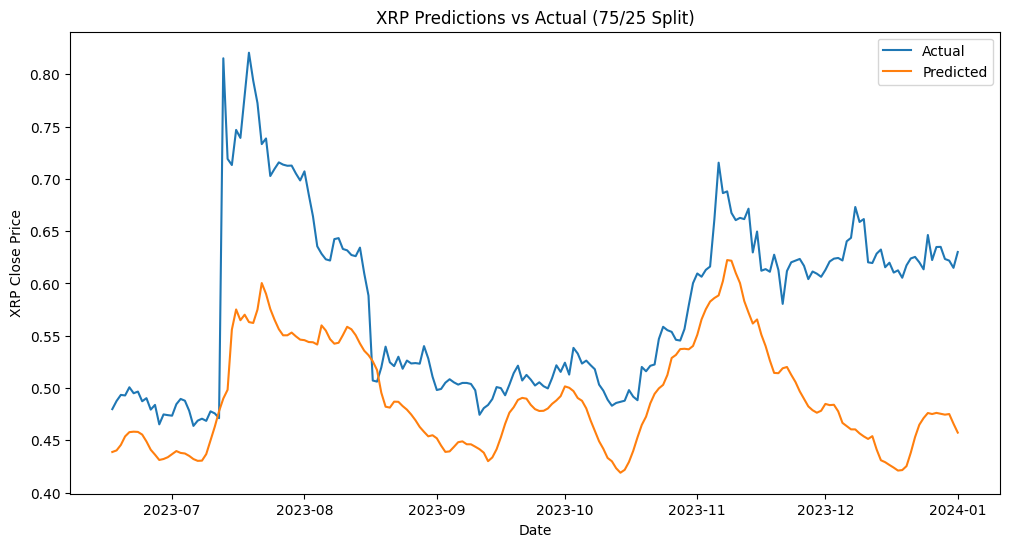

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(xrp_q3_df_plot["Actual"], label="Actual")
plt.plot(xrp_q3_df_plot["Predicted"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("XRP Close Price")
plt.title("XRP Predictions vs Actual (75/25 Split)")
plt.legend()
plt.show()